In [ ]:
import pandas as pd
df = pd.read_csv(r"F:\cgm-Analyzer\data\HUPA0001P.csv", sep=";")
print(df.head())
print(df.info())
print(df.isnull().sum())




                  time  glucose  calories  heart_rate  steps  basal_rate  \
0  2018-06-13T18:40:00    332.0    6.3595   82.322835   34.0    0.091667   
1  2018-06-13T18:45:00    326.0    7.7280   83.740157    0.0    0.091667   
2  2018-06-13T18:50:00    330.0    4.7495   80.525180    0.0    0.091667   
3  2018-06-13T18:55:00    324.0    6.3595   89.129032   20.0    0.091667   
4  2018-06-13T19:00:00    306.0    5.1520   92.495652    0.0    0.075000   

   bolus_volume_delivered  carb_input  
0                     0.0         0.0  
1                     0.0         0.0  
2                     0.0         0.0  
3                     0.0         0.0  
4                     0.0         0.0  
<class 'pandas.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   time                    4096 non-null   str    
 1   glucose                 4096 non-null   floa

There are 4096 entries with 8 columns and there is no missing values. There is one string and 7 floats.

In [3]:
mean_glucose = df["glucose"].mean()
median_glucose = df["glucose"].median()
std_glucose = df["glucose"].std()
min_glucose = df["glucose"].min()
max_glucose = df["glucose"].max()

print("Mean:", mean_glucose)
print("Median:", median_glucose)
print("Standard deviation:", std_glucose)
print("Minimum:", min_glucose)
print("Maximum:", max_glucose)

Mean: 181.4437255859375
Median: 165.66666666666666
Standard deviation: 70.64463325126245
Minimum: 40.0
Maximum: 444.0


Mean is approximately 181.44 and median is 165 which is the middle value. Mean is bit elevated making the distribution right skewed with several number of high glucose concentrations, which can be seen by the maximum of 444.0  
Sd is 70.64 with considerable variation of glucose concentrations. The wide range between 40 to 444.0 suggests the substantial variability of the data.

In [6]:
df["glucose"].describe()



count    4096.000000
mean      181.443726
std        70.644633
min        40.000000
25%       131.000000
50%       165.666667
75%       222.000000
max       444.000000
Name: glucose, dtype: float64

In [7]:
Q1 = df["glucose"].quantile(0.25)
Q3 = df["glucose"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 131.0
Q3: 222.0
IQR: 91.0


In [15]:
cv = (70.644633 / 181.443726) * 100
print(cv)

38.934734508262906


## Coefficient of Variation

The coefficient of variation (CV) was calculated to assess glucose variability relative to the mean glucose concentration.

CV was calculated using the standard deviation divided by the mean glucose value, multiplied by 100.

The mean glucose concentration was 181.44 and the standard deviation was 70.64, resulting in a coefficient of variation of approximately 38.94%.

The relatively high CV indicates substantial variability in the glucose measurements. This suggests that glucose levels fluctuated considerably relative to the average glucose concentration.

In [ ]:
# Feature Analysis
#Checking how heart rate and glucose depends
print(df[["glucose","heart_rate"]].corr())
print(df.corr(numeric_only=True))
print (df[["steps","glucose"]].corr())
print(df[["glucose","steps"]].corr())
print(df[["glucose","basal_rate"]].corr())

#Parse time
df["time"] = pd.to_datetime(df["time"])

In [17]:
# CGM Time in Range (TIR)

total_readings = len(df)

tir = ((df["glucose"] >= 70) & (df["glucose"] <= 180)).sum()
tbr = (df["glucose"] < 70).sum()
tar = (df["glucose"] > 180).sum()

print("Total readings:", total_readings)
print("TIR (70-180 mg/dL):", tir / total_readings * 100, "%")
print("Time Below Range (<70 mg/dL):", tbr / total_readings * 100, "%")
print("Time Above Range (>180 mg/dL):", tar / total_readings * 100, "%")

# More detailed CGM glucose ranges

very_low = (df["glucose"] < 54).sum()
low = ((df["glucose"] >= 54) & (df["glucose"] < 70)).sum()

in_range = ((df["glucose"] >= 70) & (df["glucose"] <= 180)).sum()

high = ((df["glucose"] > 180) & (df["glucose"] <= 250)).sum()
very_high = (df["glucose"] > 250).sum()

print("Very Low (<54):", very_low / total_readings * 100, "%")
print("Low (54-69):", low / total_readings * 100, "%")
print("TIR (70-180):", in_range / total_readings * 100, "%")
print("High (181-250):", high / total_readings * 100, "%")
print("Very High (>250):", very_high / total_readings * 100, "%")

Total readings: 4096
TIR (70-180 mg/dL): 56.494140625 %
Time Below Range (<70 mg/dL): 1.4404296875 %
Time Above Range (>180 mg/dL): 42.0654296875 %
Very Low (<54): 0.2685546875 %
Low (54-69): 1.171875 %
TIR (70-180): 56.494140625 %
High (181-250): 26.7578125 %
Very High (>250): 15.3076171875 %


The main CGM glucose categories used in this analysis are:

Time Below Range (TBR): glucose <70 mg/dL
Time in Range (TIR): glucose 70–180 mg/dL
Time Above Range (TAR): glucose >180 mg/dL

For more detailed analysis, the below- and above-range values can be divided into:

Very low: <54 mg/dL
Low: 54–69 mg/dL
In range: 70–180 mg/dL
High: 181–250 mg/dL
Very high: >250 mg/dL

Overall, approximately 56.5% of the readings were within the target range, while 42.1% were above the target range and 1.4% were below it. This indicates that, in this dataset, readings outside the target range were predominantly due to hyperglycemia rather than hypoglycemia.

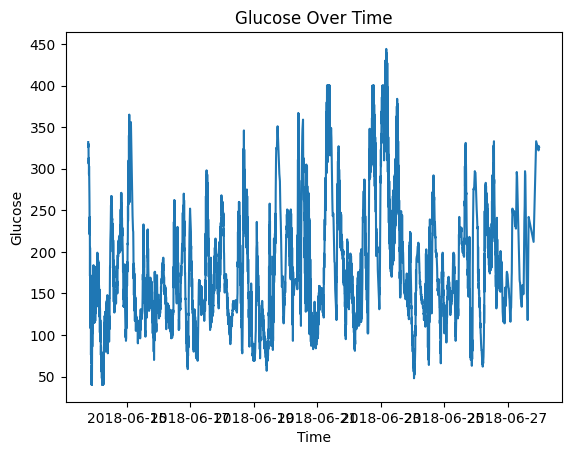

In [5]:
plt.plot(df["time"], df["glucose"])
plt.xlabel("Time")
plt.ylabel("Glucose")
plt.title("Glucose Over Time")
plt.show()

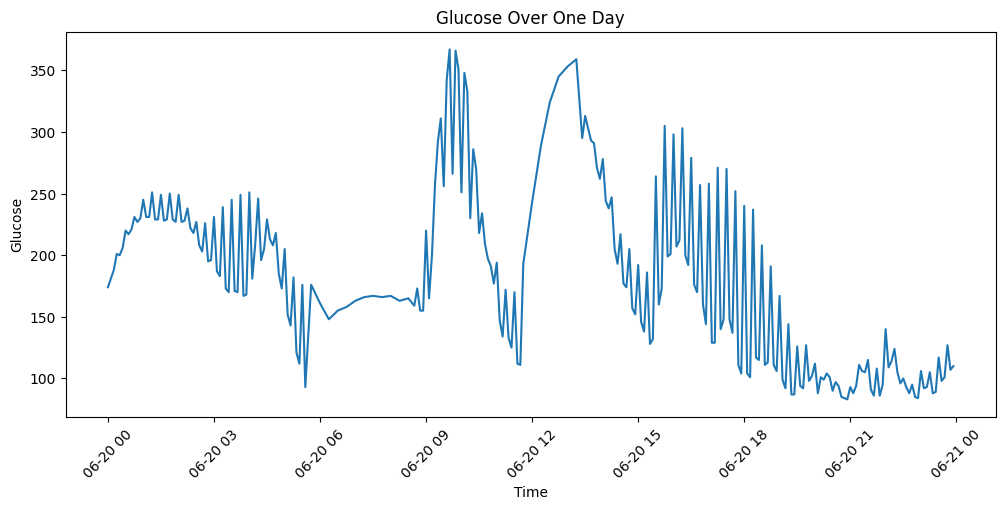

In [6]:
one_day = df[df["time"].dt.date == pd.Timestamp("2018-06-20").date()]

plt.figure(figsize=(12,5))
plt.plot(one_day["time"], one_day["glucose"])

plt.xlabel("Time")
plt.ylabel("Glucose")
plt.title("Glucose Over One Day")

plt.xticks(rotation=45)
plt.show()

##Analysis
The graph shows substantial variability of glucose throughout the day. There are glucose excursions can be observed arount 9 to 10 in the morning and 12 to 1 in the afternoon. 
In the early afternoon, the glucose is generally lower but with rapid changes. 
This can be due to meal intakes, but cannot drive in to conclusions only based on this, we need to consider the exercices, medications and stress levels.

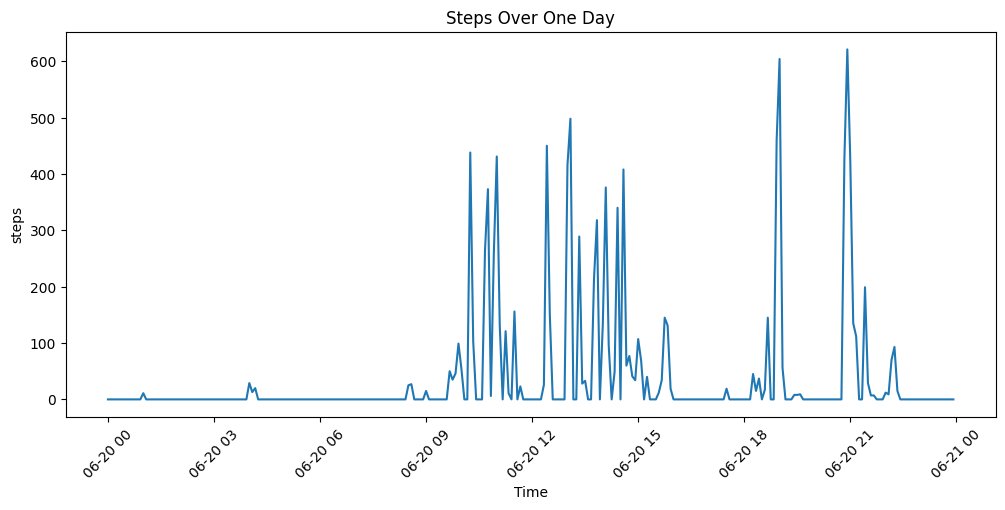

In [9]:
one_day = df[df["time"].dt.date == pd.Timestamp("2018-06-20").date()]

plt.figure(figsize=(12,5))
plt.plot(one_day["time"], one_day["steps"])

plt.xlabel("Time")
plt.ylabel("steps")
plt.title("Steps Over One Day")

plt.xticks(rotation=45)
plt.show()

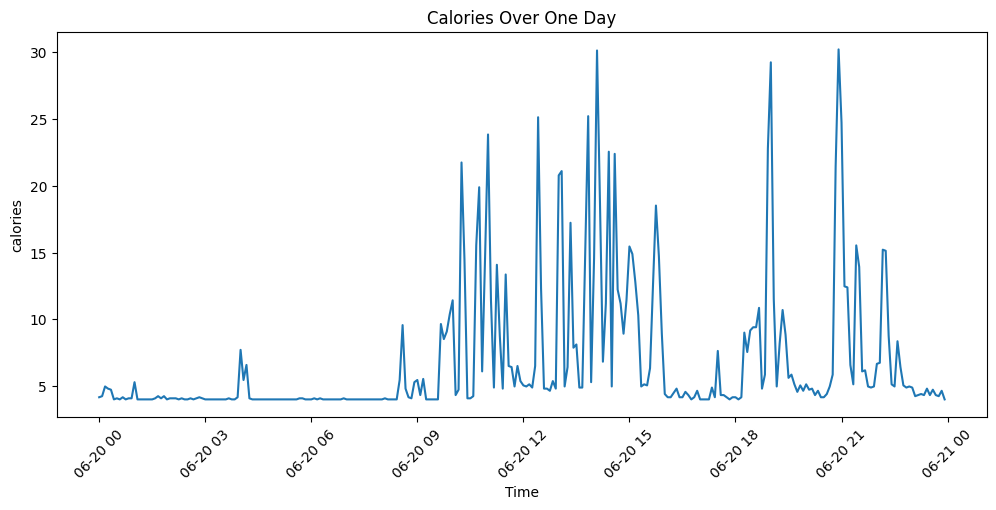

In [10]:
one_day = df[df["time"].dt.date == pd.Timestamp("2018-06-20").date()]

plt.figure(figsize=(12,5))
plt.plot(one_day["time"], one_day["calories"])

plt.xlabel("Time")
plt.ylabel("calories")
plt.title("Calories Over One Day")

plt.xticks(rotation=45)
plt.show()

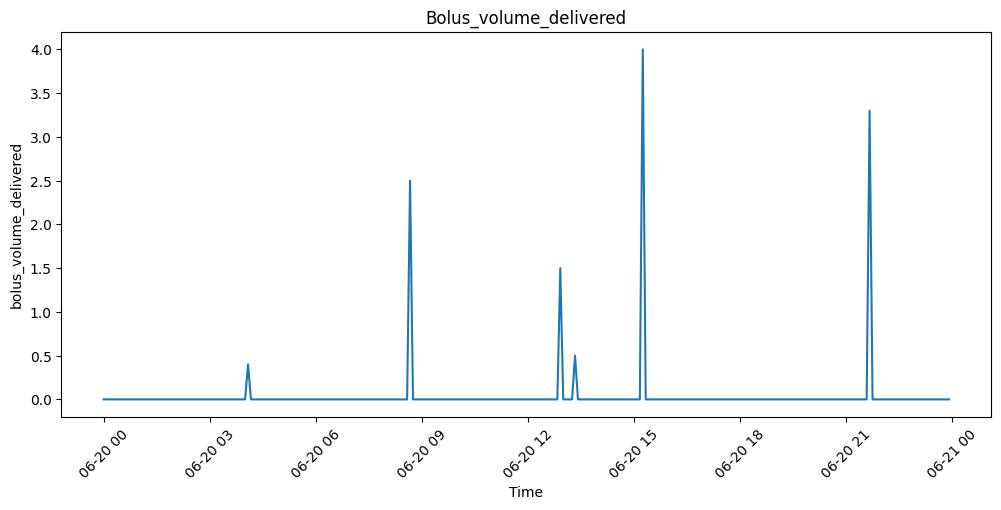

In [11]:
one_day = df[df["time"].dt.date == pd.Timestamp("2018-06-20").date()]

plt.figure(figsize=(12,5))
plt.plot(one_day["time"], one_day["bolus_volume_delivered"])

plt.xlabel("Time")
plt.ylabel("bolus_volume_delivered")
plt.title("Bolus_volume_delivered")

plt.xticks(rotation=45)
plt.show()

Interpretation
The glucose excursions, possible cause maybe the calorie intake. The genrally lower glucose values after the excursions can be resulted by the steps and blus amount that recieved.

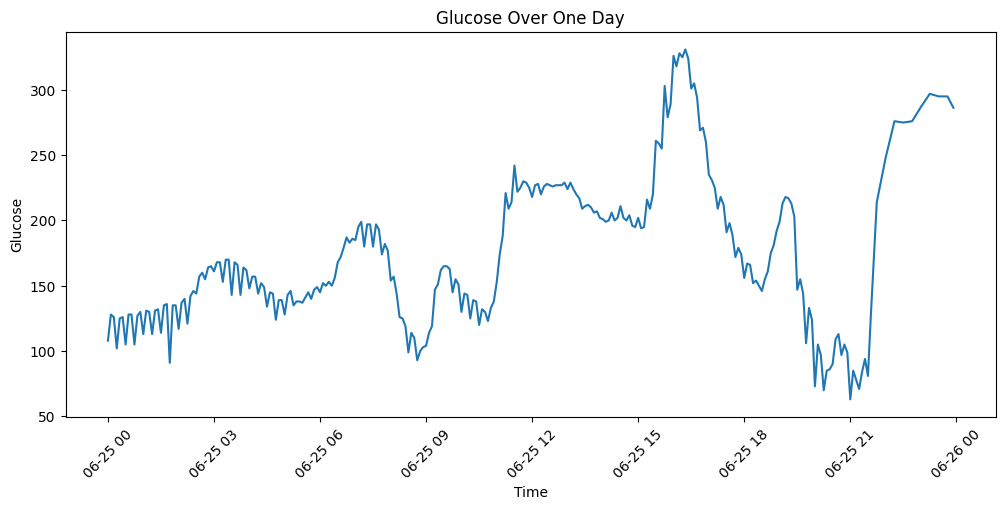

In [7]:
one_day = df[df["time"].dt.date == pd.Timestamp("2018-06-25").date()]

plt.figure(figsize=(12,5))
plt.plot(one_day["time"], one_day["glucose"])

plt.xlabel("Time")
plt.ylabel("Glucose")
plt.title("Glucose Over One Day")

plt.xticks(rotation=45)
plt.show()

##Analysis
substantial variablity of glucose. And can be seen glucose excursions around 4 in the afternoon. Overall there is nt rapid changes. This excursions possible due to mean intakes, it cannot be determined only by this. Possible exercises, medications, illnesses and stress levels can also affected. 

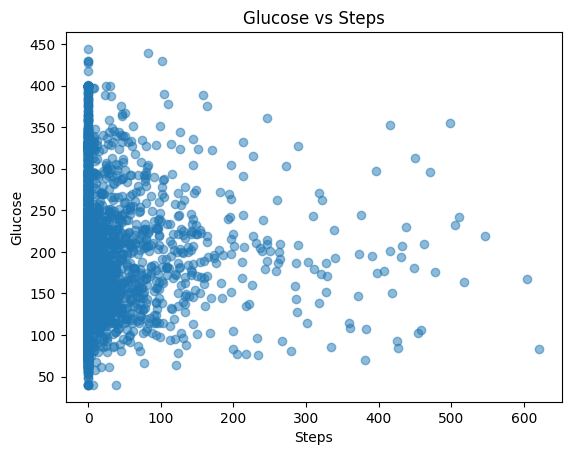

In [12]:
import matplotlib.pyplot as plt
plt.scatter(df["steps"], df["glucose"], alpha=0.5)
plt.xlabel("Steps")
plt.ylabel("Glucose")
plt.title("Glucose vs Steps")
plt.show()

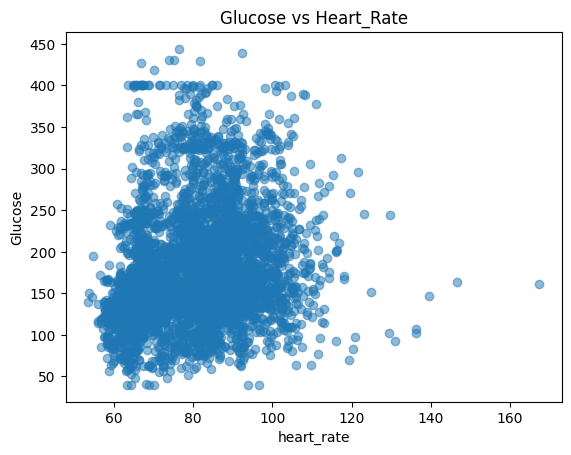

In [13]:
plt.scatter(df["heart_rate"], df["glucose"], alpha=0.5)
plt.xlabel("heart_rate")
plt.ylabel("Glucose")
plt.title("Glucose vs Heart_Rate")
plt.show()

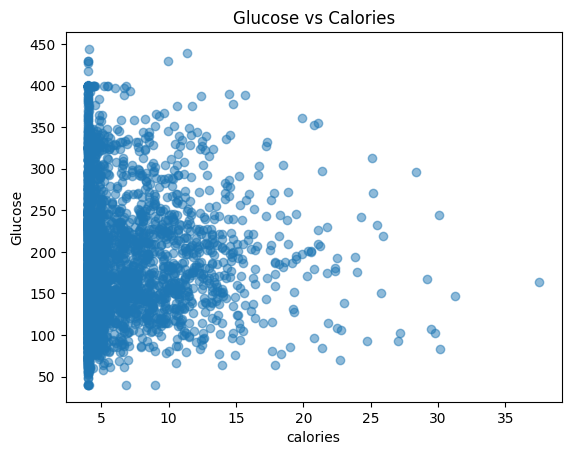

In [14]:
plt.scatter(df["calories"], df["glucose"], alpha=0.5)
plt.xlabel("calories")
plt.ylabel("Glucose")
plt.title("Glucose vs Calories")
plt.show()

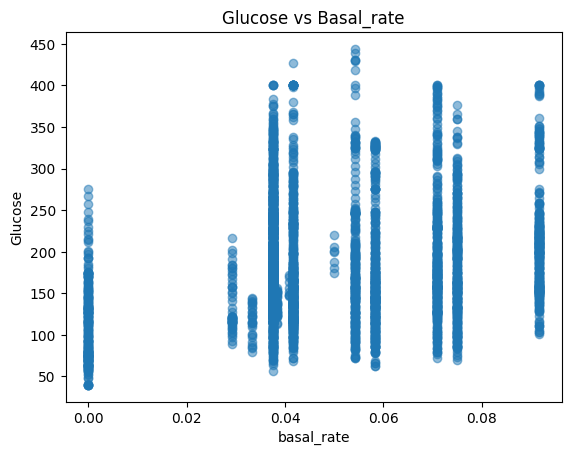

In [15]:
plt.scatter(df["basal_rate"], df["glucose"], alpha=0.5)
plt.xlabel("basal_rate")
plt.ylabel("Glucose")
plt.title("Glucose vs Basal_rate")
plt.show()

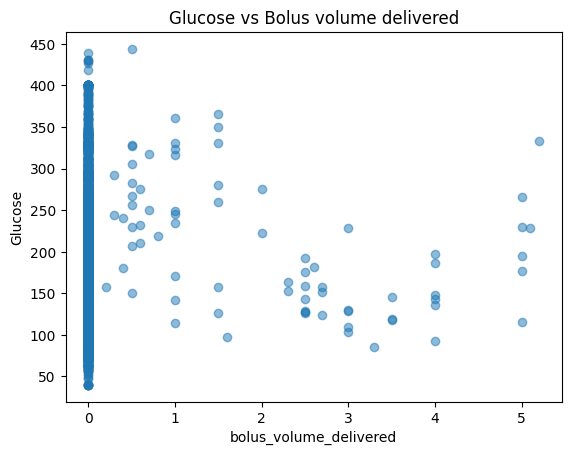

In [16]:
plt.scatter(df["bolus_volume_delivered"], df["glucose"], alpha=0.5)
plt.xlabel("bolus_volume_delivered")
plt.ylabel("Glucose")
plt.title("Glucose vs Bolus volume delivered")
plt.show()

There is no positive or negative realtionship with steps heart rate and calories. 

Q1: 131.0
Q3: 222.0
IQR: 91.0


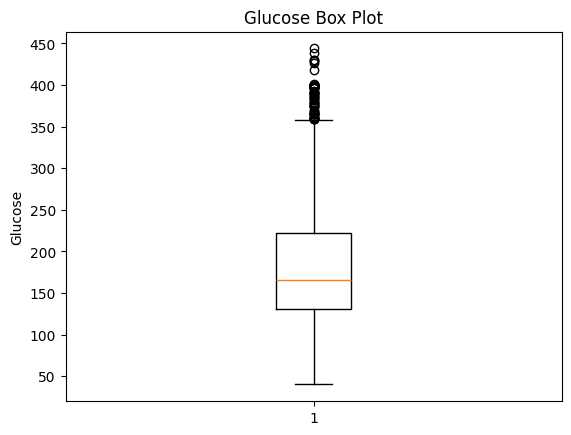

In [14]:
Q1 = df["glucose"].quantile(0.25)
Q3 = df["glucose"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

plt.boxplot(df["glucose"].dropna())
plt.ylabel("Glucose")
plt.title("Glucose Box Plot")
plt.show()

The box plot reveals that glucose measurements are positively skewed, with a median of approximately 165 mg/dL and an interquartile range of 130–220 mg/dL. Numerous high-value outliers above 360 mg/dL indicate frequent hyperglycemic events, while a few low glucose readings near 40 mg/dL suggest occasional hypoglycemic episodes. Overall, the dataset demonstrates substantial glucose variability, highlighting the importance of considering additional factors such as meal intake, insulin administration, and physical activity when analyzing glucose trends.

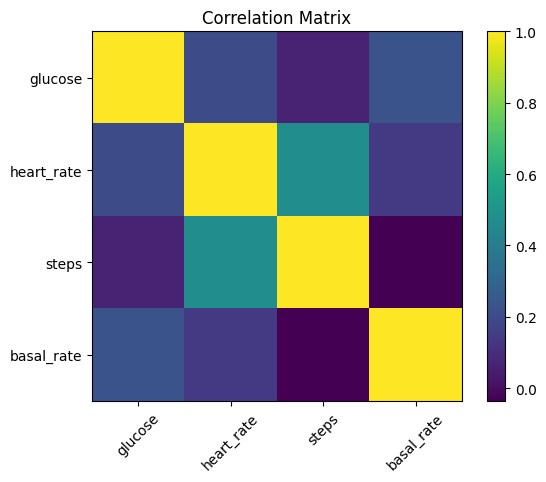

In [18]:
corr = df[["glucose", "heart_rate", "steps", "basal_rate"]].corr()

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

# Correlation Matrix Analysis


The correlation matrix indicates that most variables have **weak linear relationships**. The strongest association is between **heart rate and step count**, which is consistent with normal physiological responses during physical activity. Glucose shows only weak correlations with heart rate, step count, and basal insulin rate, suggesting that glucose regulation is influenced by multiple interacting factors rather than any single variable. Therefore, accurately predicting glucose levels is likely to require a multivariable approach rather than relying on one physiological measurement alone.
